# Figure 7 - Daughter-specific Story

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.sgd import read_nondubious_genes_dataset
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

output_dir = 'output/draft4_run/'
genome_deconv_analysis = GenomeDeconvolutionAnalysis(
    output_dir)


In [4]:
from pipeline.chromatin_metrics_processor import ChromatinMetricsProcessor

chromatin_metrics_processor = ChromatinMetricsProcessor(output_dir)


In [5]:
chromatin_metrics_processor.setup_data_loaders()

In [6]:
chromatin_metrics_processor.load_and_assign_saved_metrics()

Loading saved data from output/draft4_run//chromatin_metrics...
  Loading deconvolved data...
    Loaded promoter_occupancy: 9663 genes, 257 timepoints
    Loaded nucleosome_entropy: 9663 genes, 257 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 257 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep1 data...
    Loaded promoter_occupancy: 9663 genes, 16 timepoints
    Loaded nucleosome_entropy: 9663 genes, 16 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 16 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep2 data...
    Loaded promoter_occupancy: 9663 genes, 15 timepoints
    Loaded nucleosome_entropy: 9663 genes, 15 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 15 timepoints
    Loaded promoter_occupancy PTRs: 9663 gen

In [7]:
from src.config import load_default_chrom_configs
config1, config2 = load_default_chrom_configs()

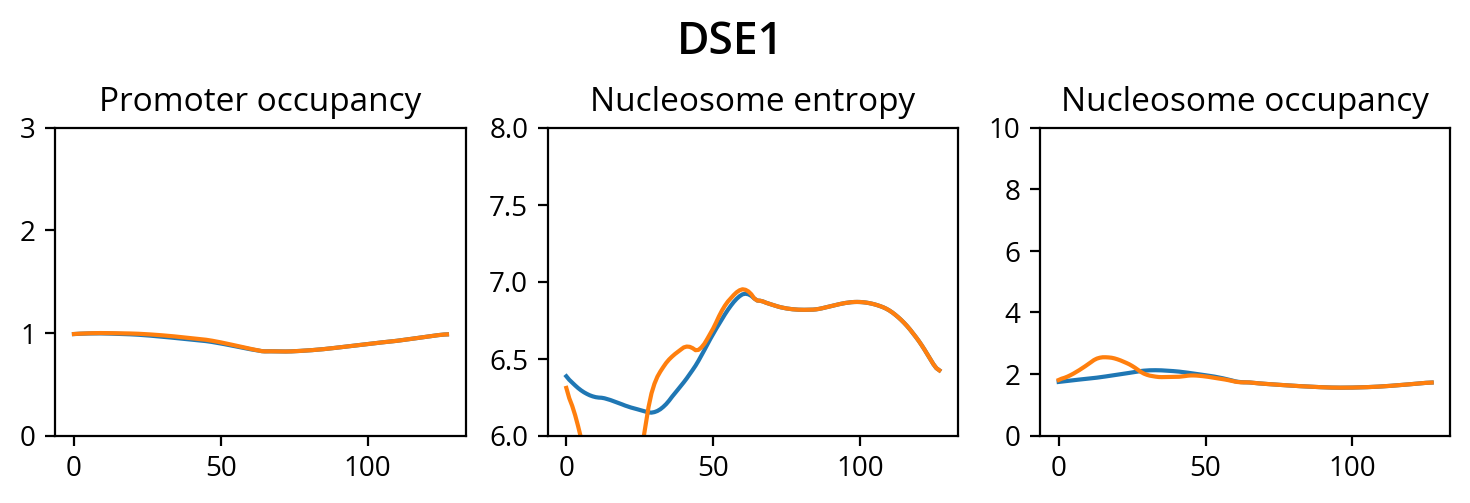

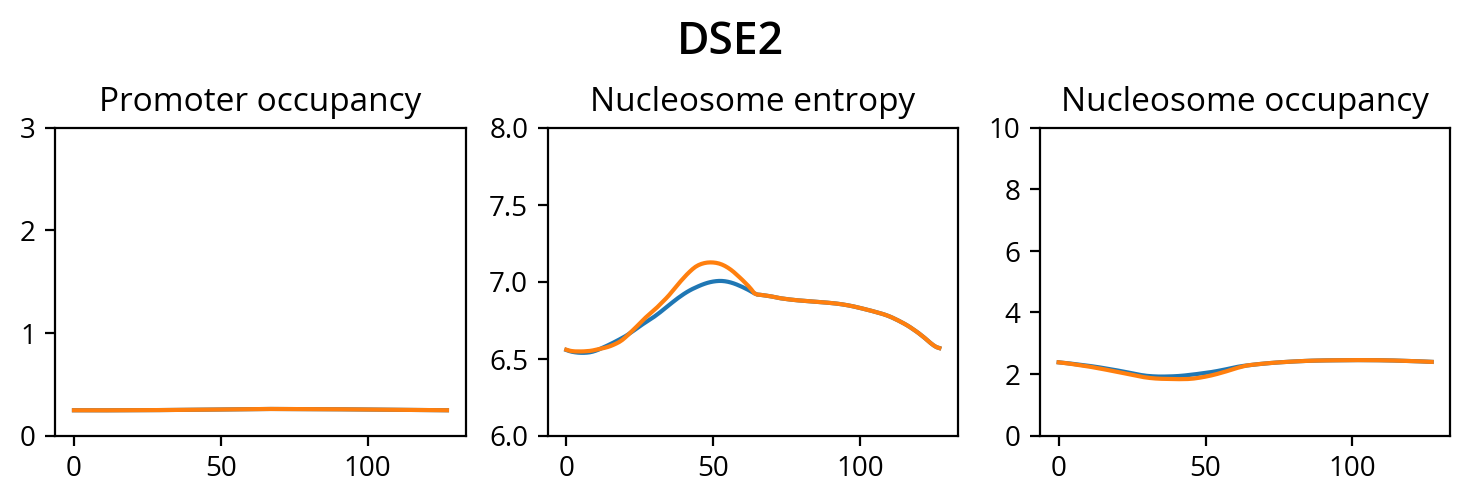

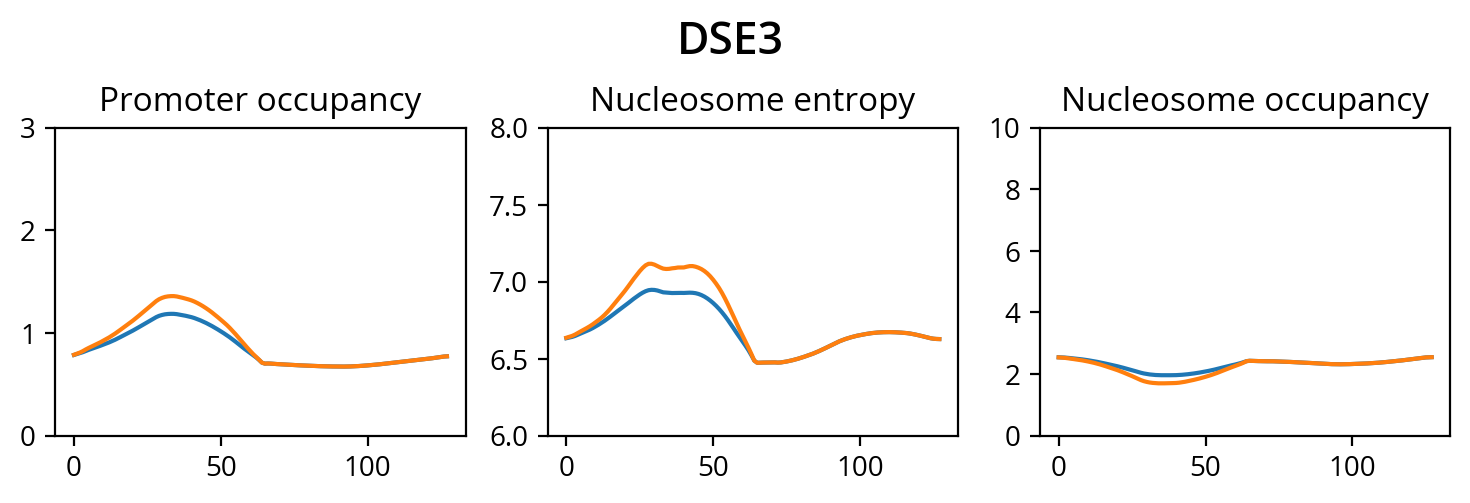

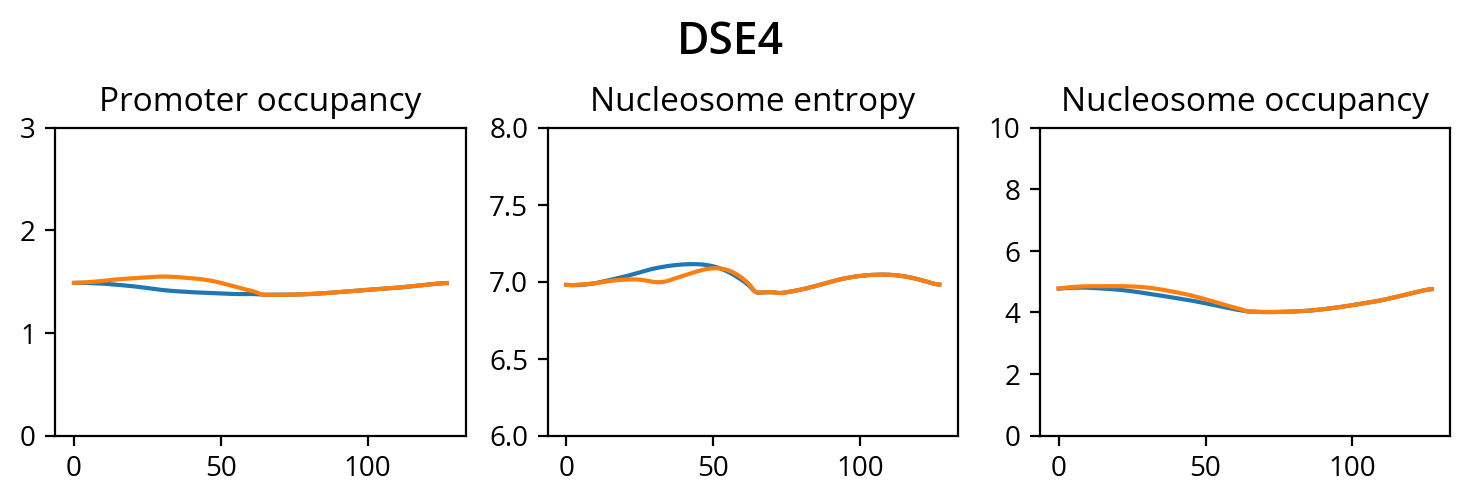

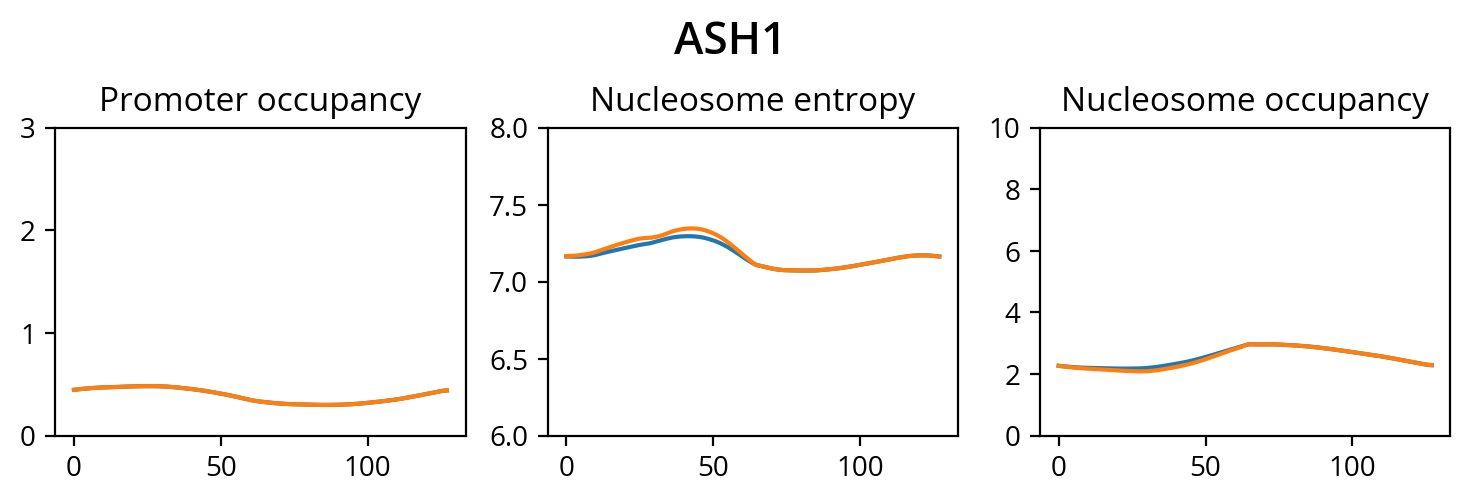

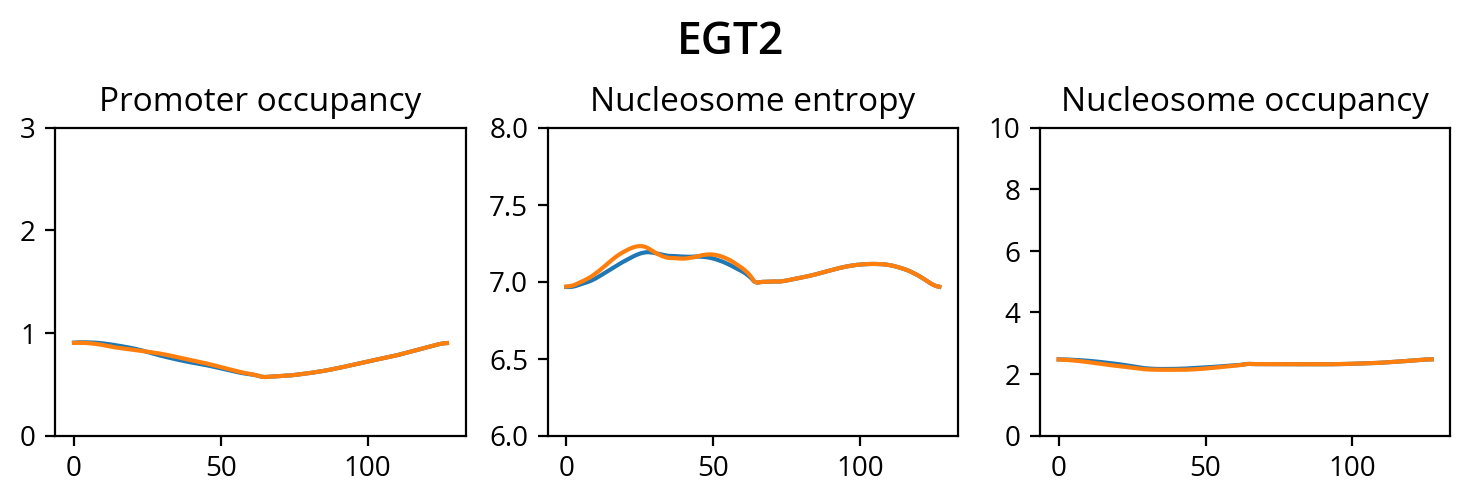

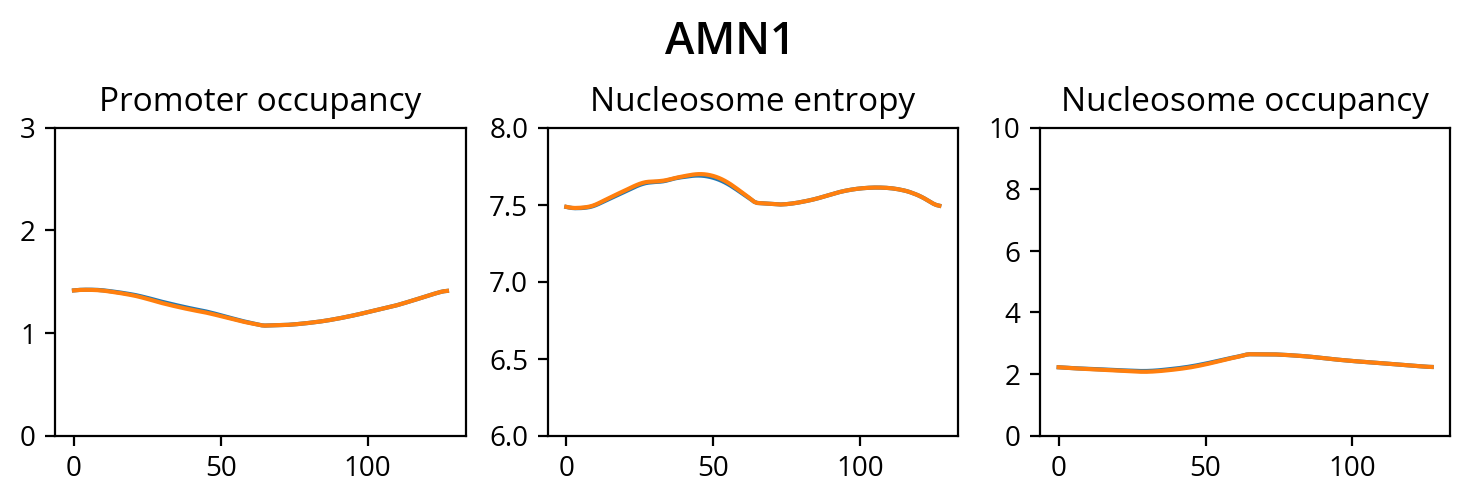

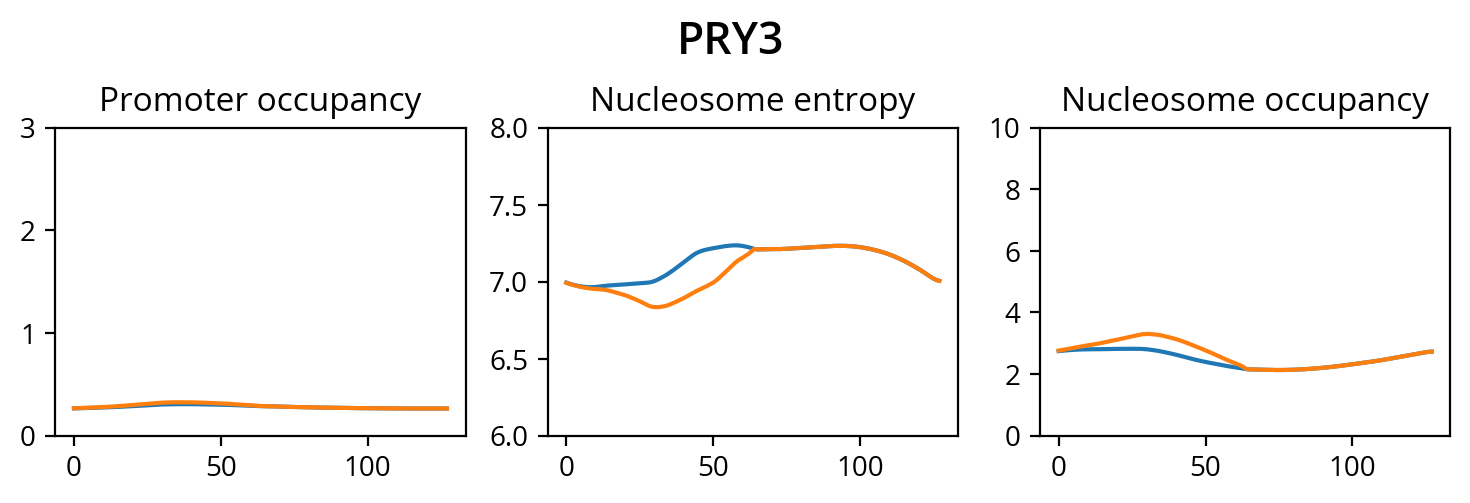

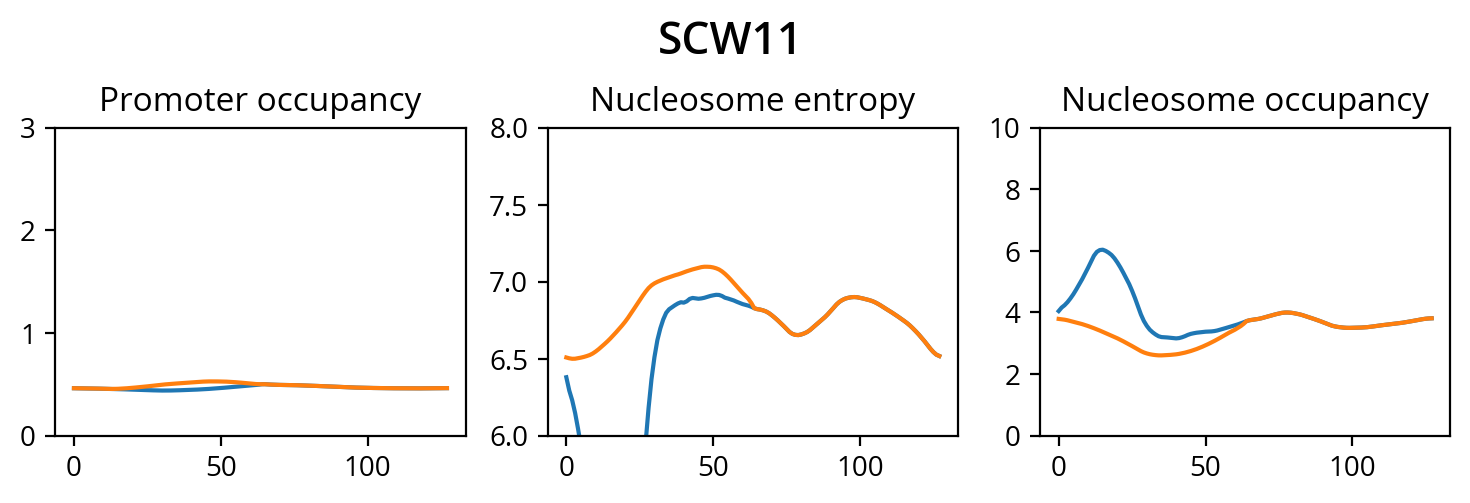

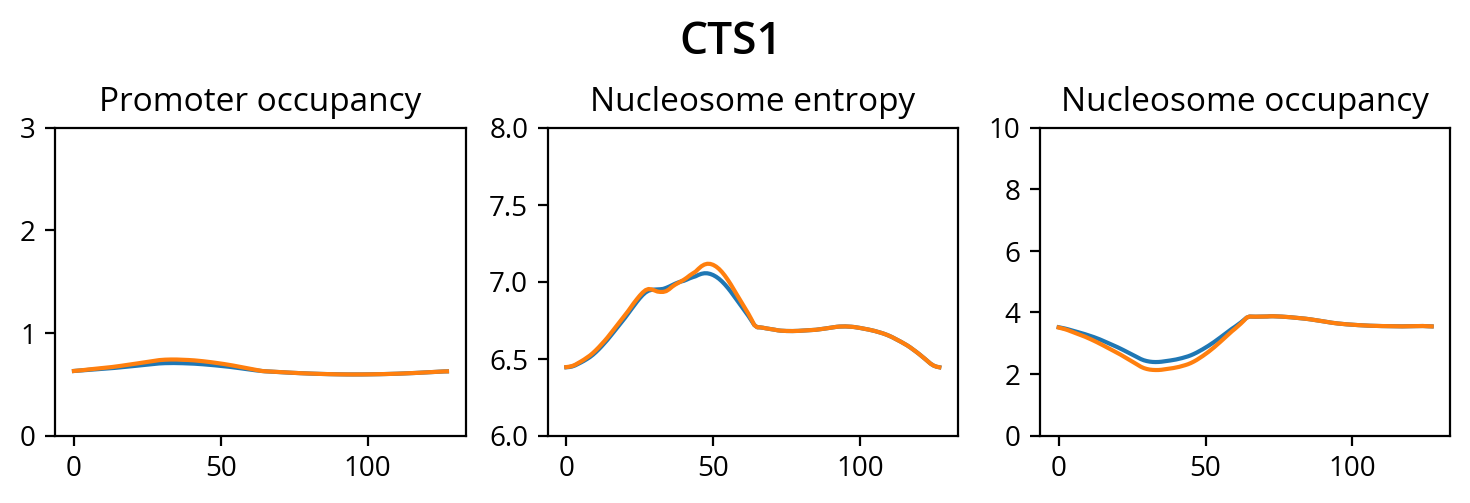

In [8]:
# Quick divegence to examine the daughter-specific chroamtin
from src.sgd import get_orfname

gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4', 'ASH1', 'EGT2', 'AMN1', 
              'PRY3', 'SCW11', 'CTS1']

for gene_name in gene_names:
    orf_name = get_orfname(gene_name)
    b_indices = config1.b_indices()
    t_indices = config1.t_indices()

    plt.figure(figsize=(9, 2))
    
    def plot_chromatin_key(chromatin_key):
        chromatin_values = chromatin_metrics_processor.deconvolved_chromatin_metrics[chromatin_key].loc[orf_name]
        plt.plot(chromatin_values[t_indices].values)
        plt.plot(chromatin_values[b_indices].values)
        
    plt.subplot(1, 3, 1)
    plot_chromatin_key('promoter_occupancy')
    plt.ylim(0, 3)
    plt.title('Promoter occupancy')
    
    plt.subplot(1, 3, 2)
    plot_chromatin_key('nucleosome_entropy')
    plt.ylim(6, 8)
    plt.title('Nucleosome entropy')
    
    plt.subplot(1, 3, 3)
    plot_chromatin_key('nucleosome_occupancy')
    plt.ylim(0, 10)
    plt.title('Nucleosome occupancy')

    plt.suptitle(gene_name, y=1.15, fontweight='demi', fontsize=16)
    

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 5
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr5.h5, crick_rna_seq_pileup_rep1_chr5.h5
Shape: (16, 576874) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr5.h5, crick_rna_seq_pileup_rep2_chr5.h5
Shape: (14, 576874) (timepoints x positions)


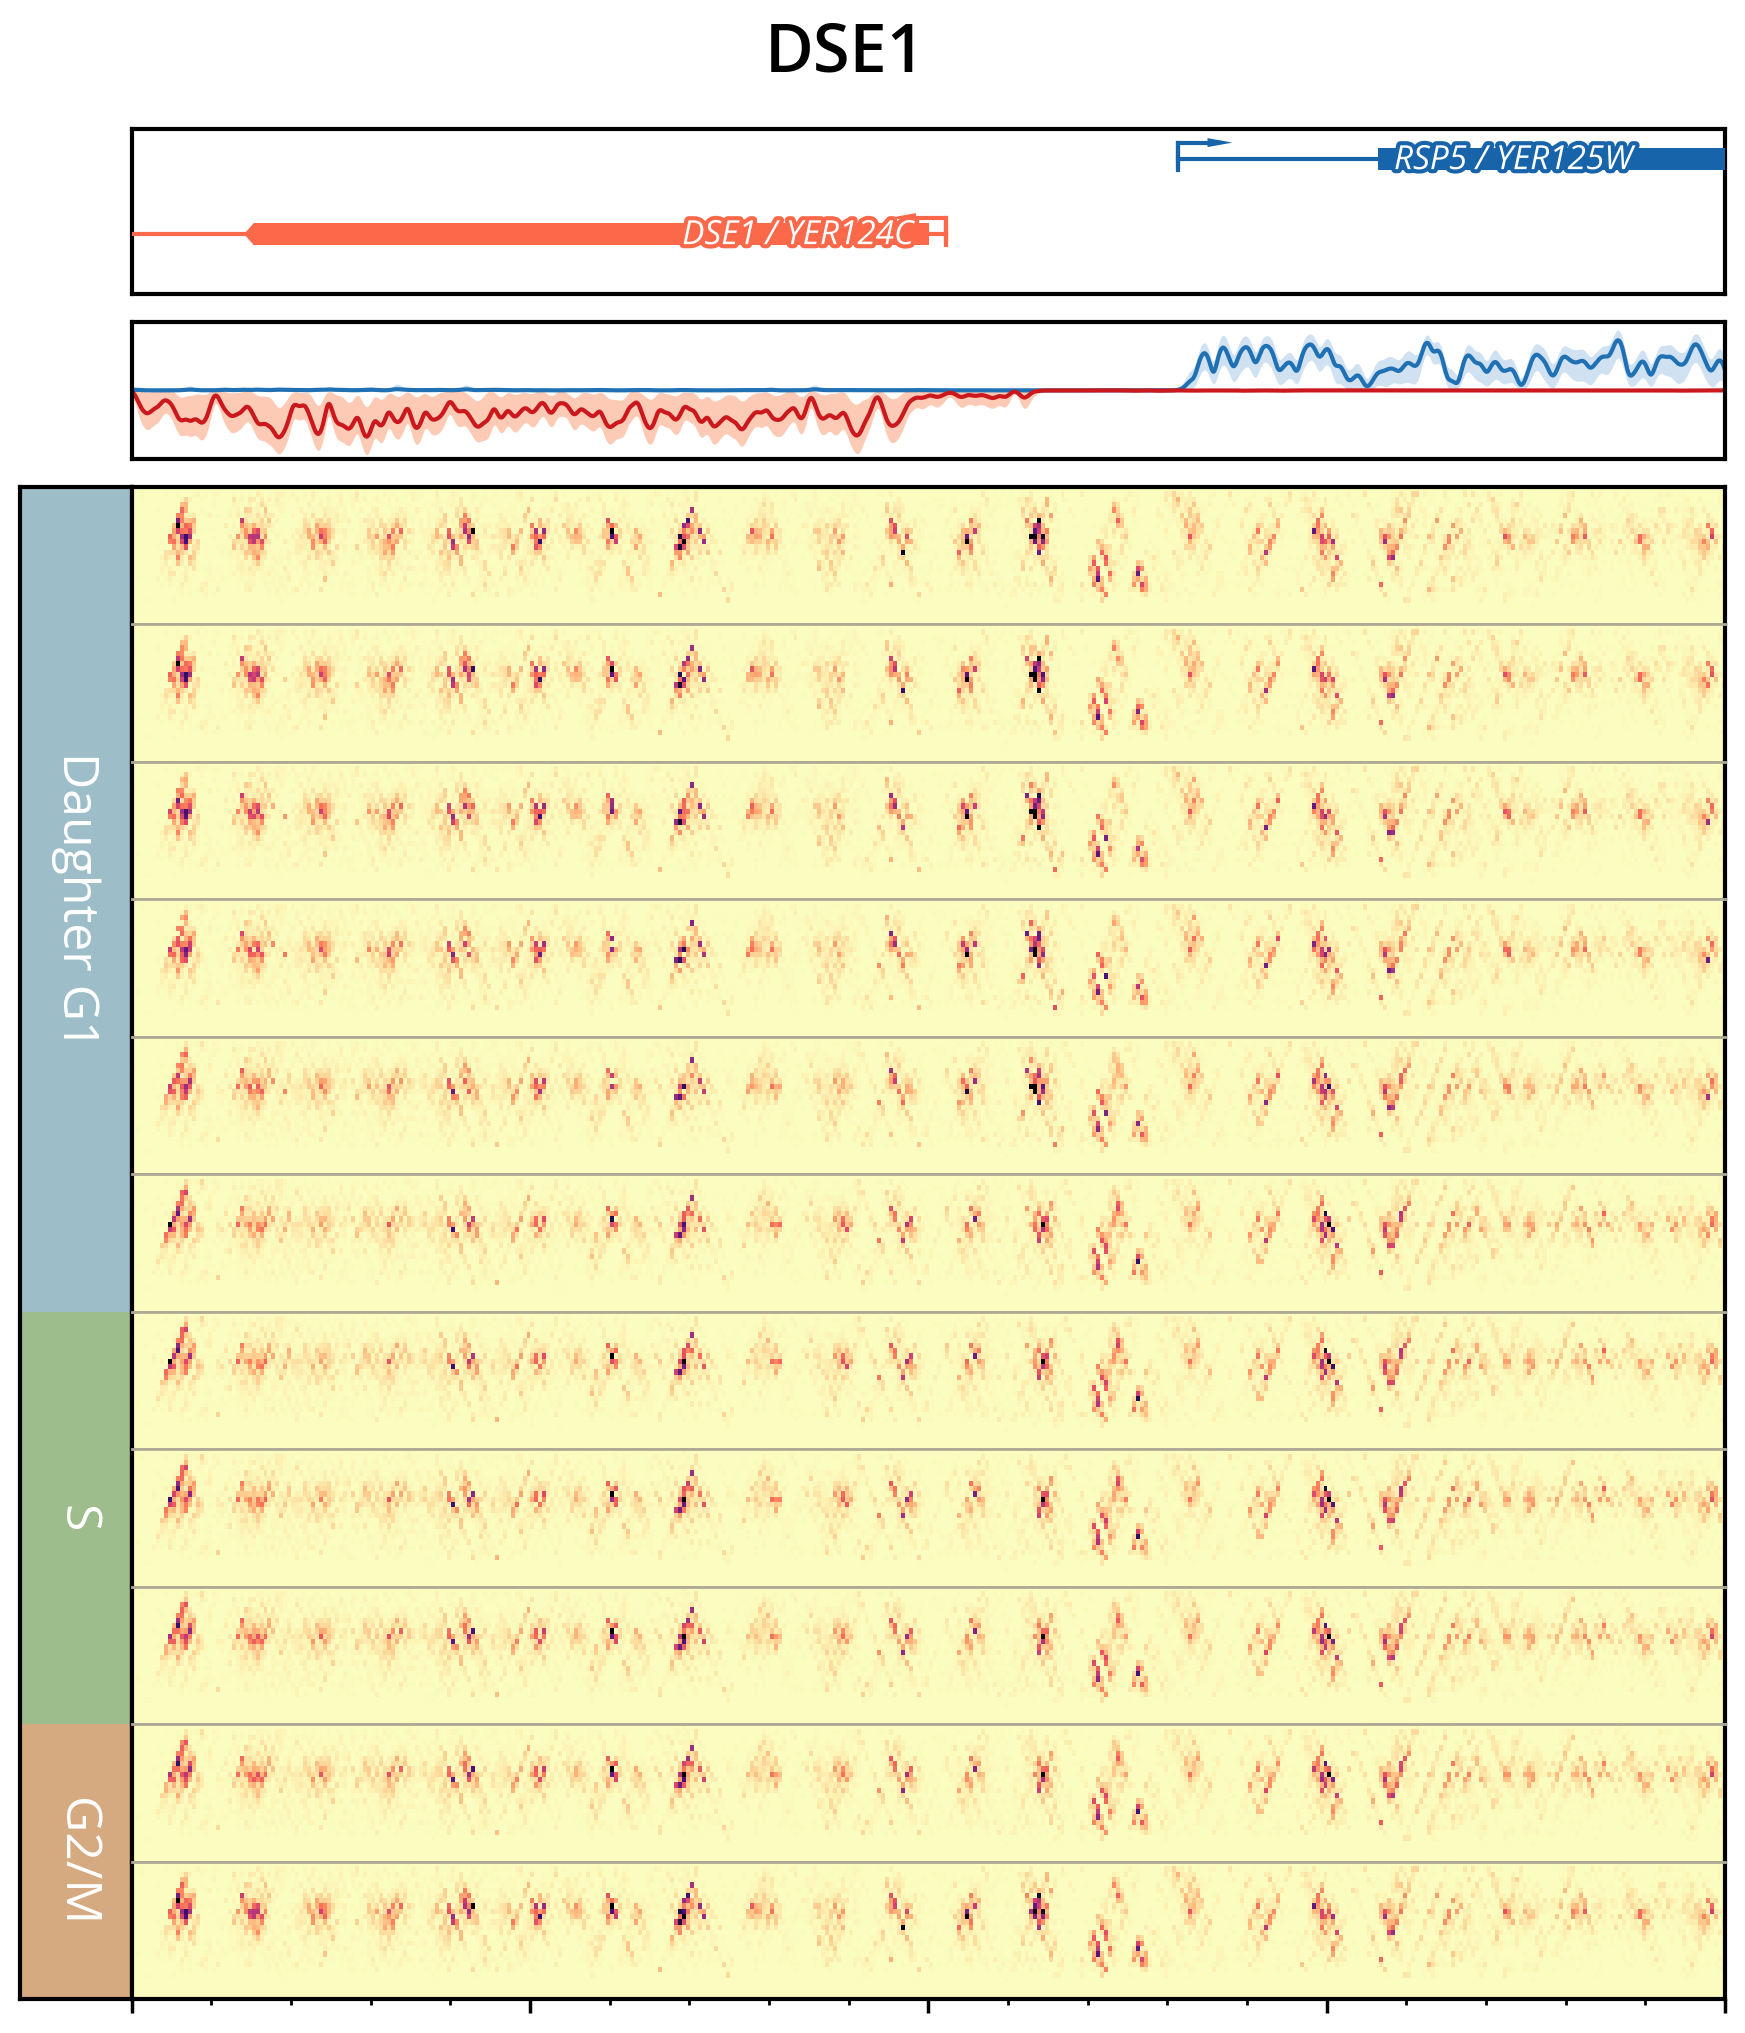

In [29]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genes = read_nondubious_genes_dataset()
gene = genes[genes['gene'] == 'DSE1'].iloc[0]
chrom = gene.chr
center = gene.stop

span = center-2000, center+2000
loaded_data = genome_deconv_analysis.load_mnase_span(chrom, span)
genome_deconv_analysis.plot_loaded_data(figsize=(11, 11), title=gene['gene'],
                                   branch_type='daughter')


Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 5
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr5.h5, crick_rna_seq_pileup_rep1_chr5.h5
Shape: (16, 576874) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr5.h5, crick_rna_seq_pileup_rep2_chr5.h5
Shape: (14, 576874) (timepoints x positions)


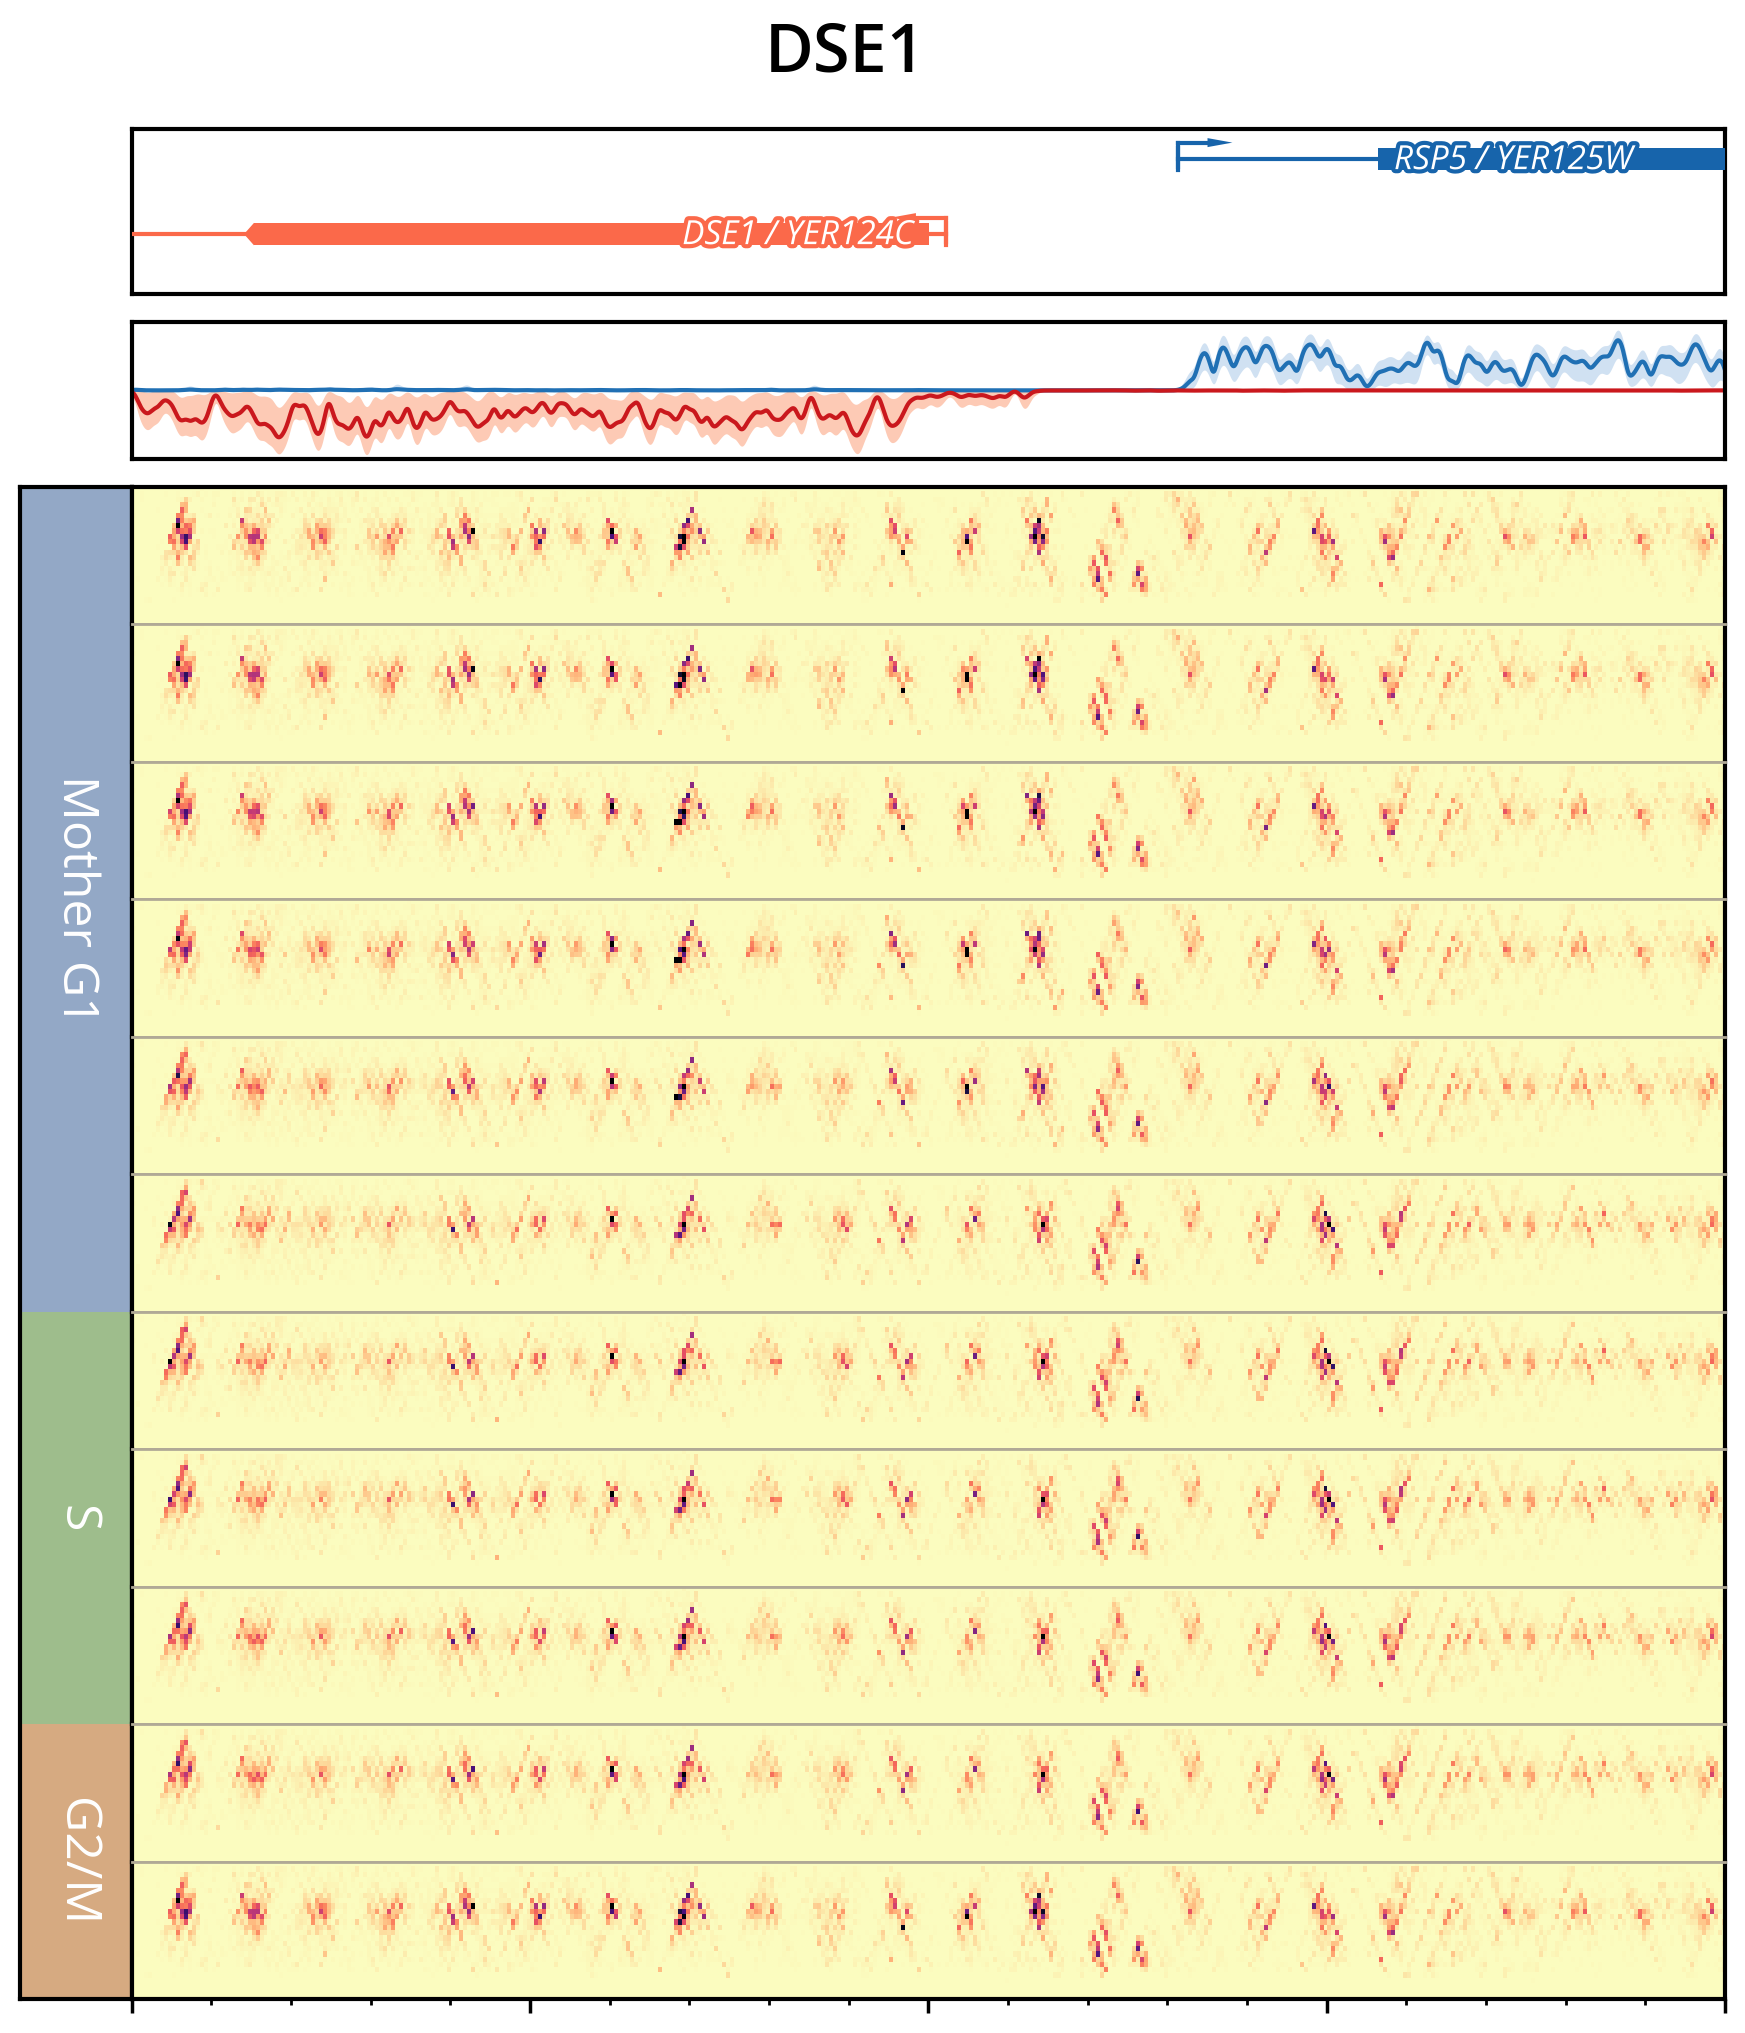

In [30]:
genome_deconv_analysis.plot_loaded_data(figsize=(11, 11), title=gene['gene'],
                                   branch_type='mother')

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 5
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr5.h5, crick_rna_seq_pileup_rep1_chr5.h5
Shape: (16, 576874) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr5.h5, crick_rna_seq_pileup_rep2_chr5.h5
Shape: (14, 576874) (timepoints x positions)


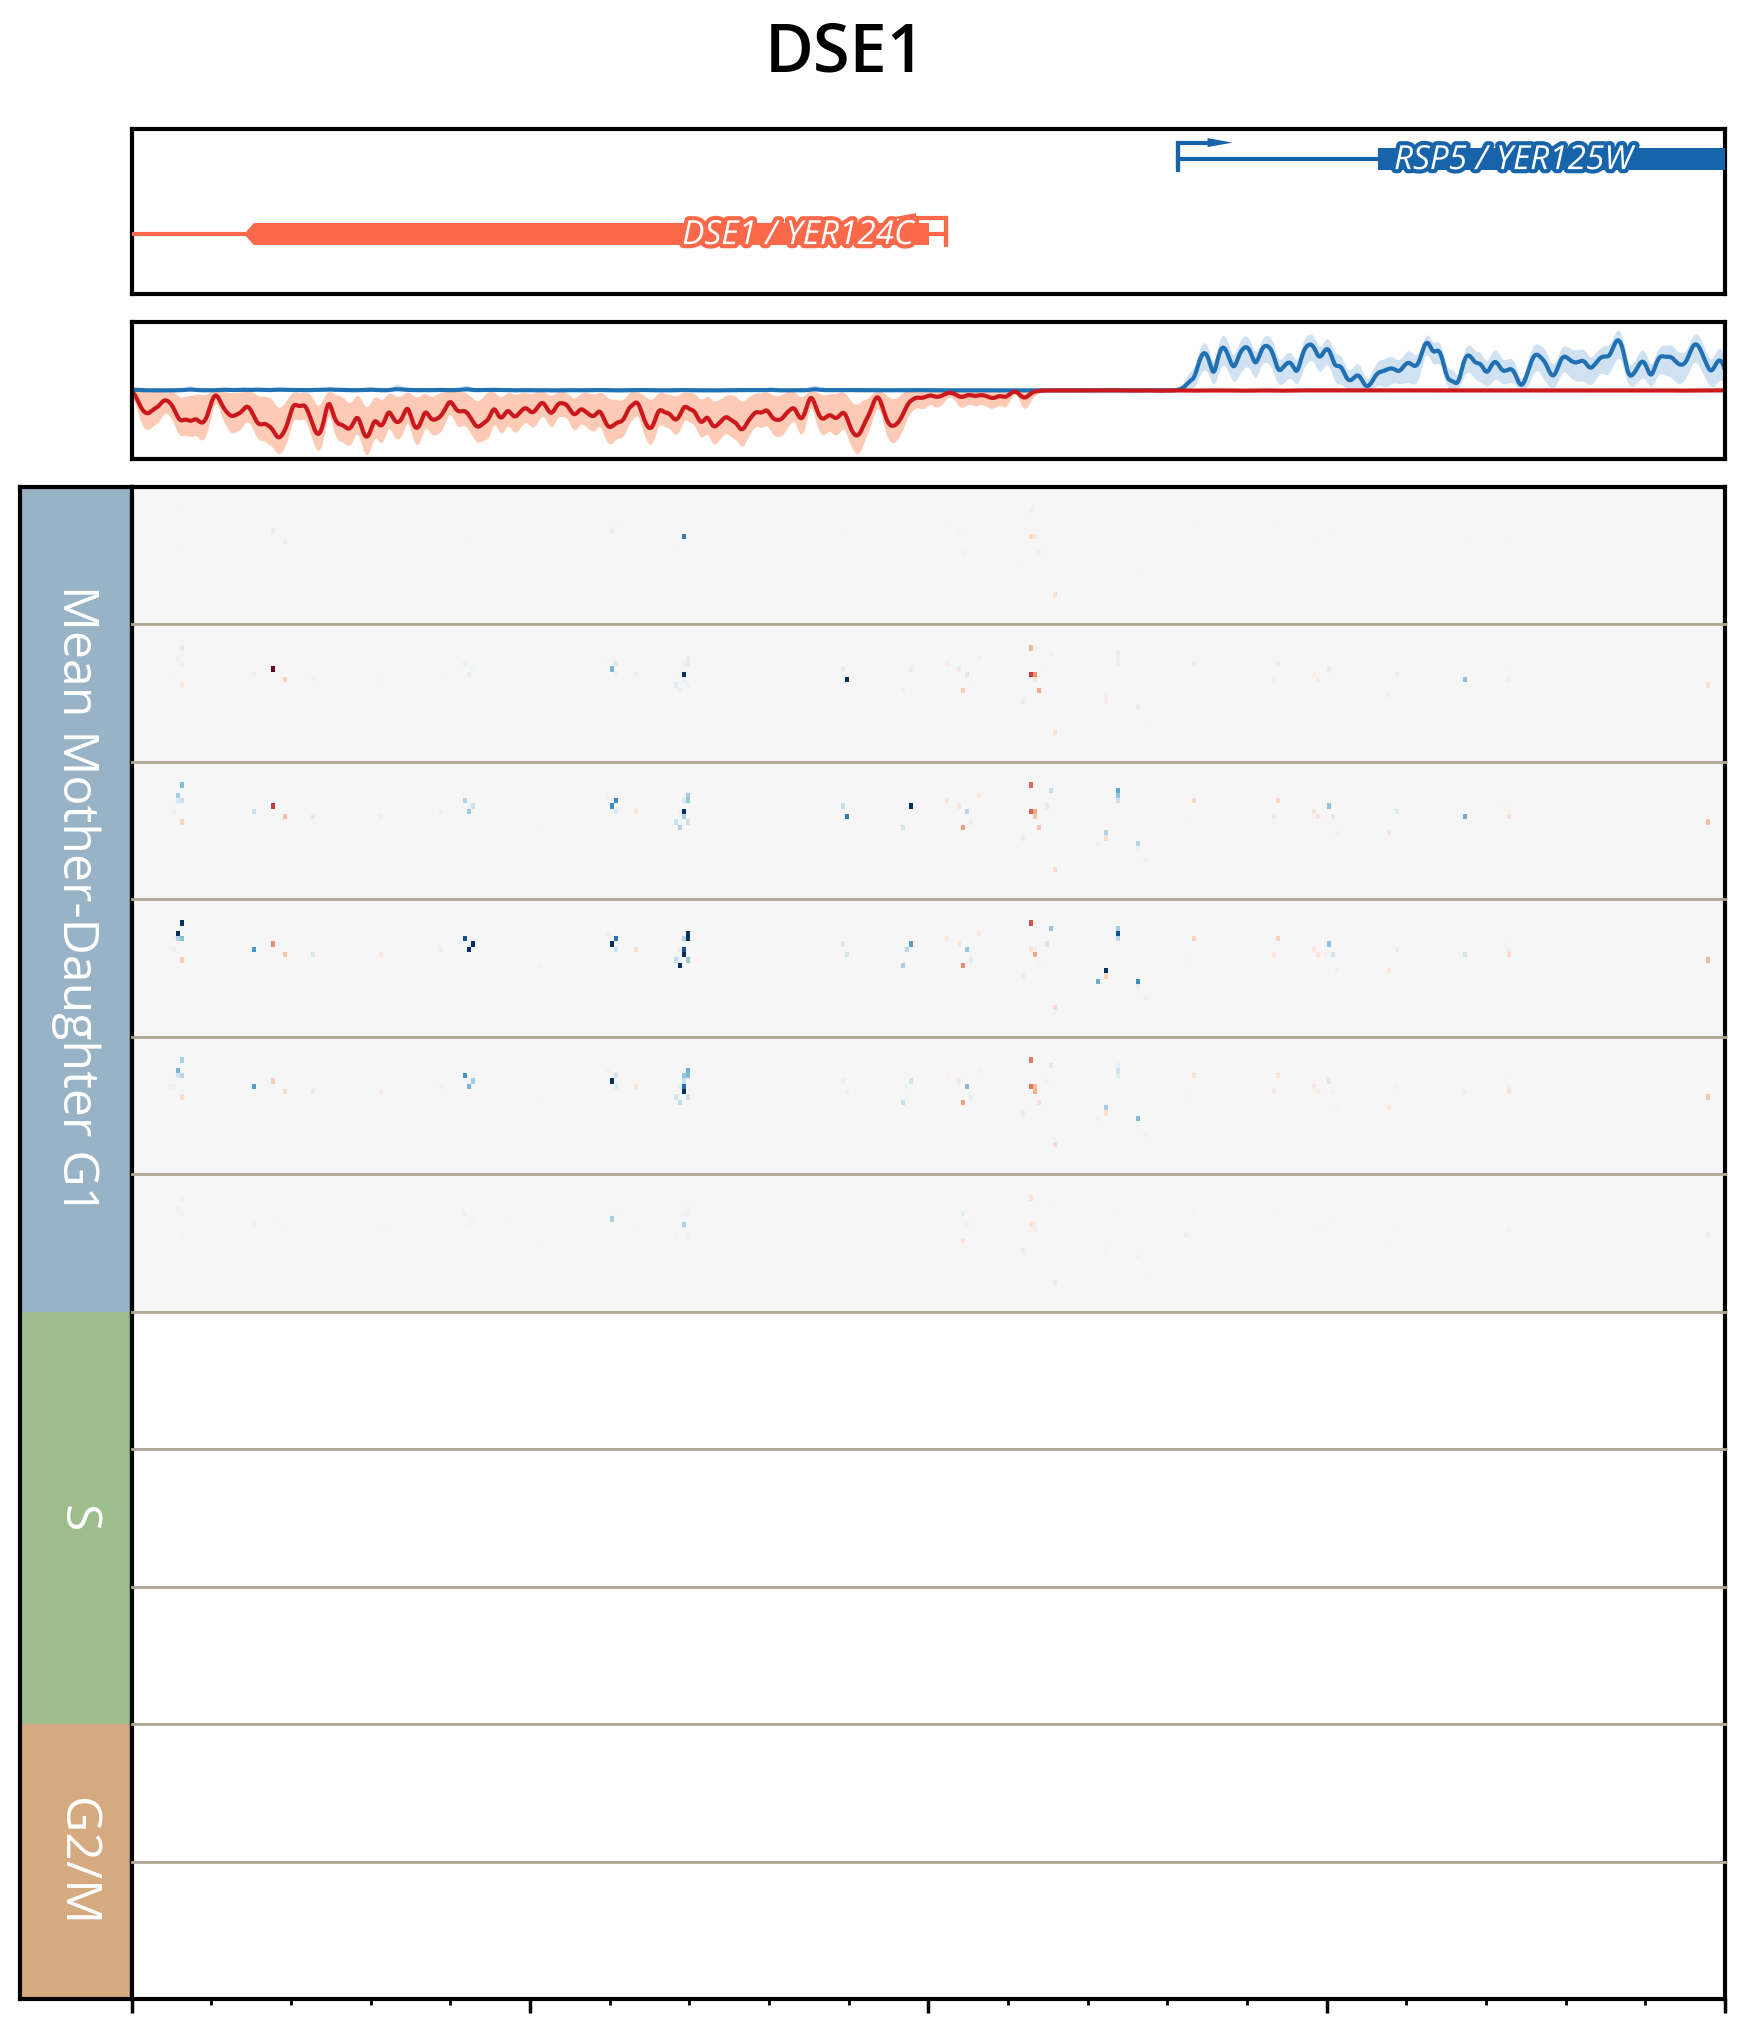

In [31]:
genome_deconv_analysis.plot_loaded_data(figsize=(11, 11), title=gene['gene'],
                                   branch_type='difference_mother_daughter')